# Introduction

Continued exploration fo reconstruction error behavior using Graph Autoencoder, to capture the graph features of the Elliptic dataset. 

**Hypothesis (H1):** unchanged

**Justification:** GAE introduces the first method that explicitly uses the graph topology during encoding. A Graph Convolutional Network (GCN) encoder aggregates each node's neighborhood:
      z_i = GCN(x_i, {x_j : j ∈ N(i)})

A transaction's embedding is informed by who it transacts with and their features.

- If AUC improves over static AE → graph topology carries signal the encoder can use, even if prior graph feature experiments (degree, PageRank) failed 
- If AUC remains ≤ 0.5 → the heterogeneity of the Elliptic graph prevents any unsupervised latent-space method from leveraging topology for anomaly detection.
Which is evidence for H0 across all method families.

**Results:** unchanged. Graph features did not add to the interpretation of the licit vs illicit transaction structures. also here, reconstrcution error variance remains hihg in licit transactions, with higher mean for licit vs. illicit. 
Accordingly, very low AUC

### colab installs

In [15]:
import sys

In [ ]:
if 'google.colab' in sys.modules:
    !pip install torch
    version = torch.__version__.split('+')[0].replace('.', '')
    !pip install torch_geometric
    !pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html
    !pip install scikit-learn
    !pip install matplotlib as plt, pandas as pd
    
    import torch

# Imports

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

import torch                                                                              
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected



/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data loading

In [2]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


In [3]:
cols = ['txId','time_step']


local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols

In [4]:
feature_cols = local_cols + agg_cols

In [5]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [9]:
# map classes: original licit: 2, original illicit: 1, unknown. 

class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True)
classes['class'] = classes['class'].astype(int)


In [10]:
df = pd.merge(features, classes, on='txId')

# Data Preparation

In [ ]:
# for training the GAE, use all the data for neighborhood aggregation, but train only on the licit class. 
def build_subgraph(df, edges, feature_cols, scaler=None):
    
    """
    Build a PyG Data object for the full graph.
    Scaler fitted on train_node_ids only.
    train_mask marks licit training nodes for loss computation.
    """
    node_ids = df['txId'].values
    node_to_idx = {nid: i for i, nid in enumerate(node_ids)}

    # edges within the graph
    mask = edges['txId1'].isin(node_to_idx) & edges['txId2'].isin(node_to_idx)
    rel  = edges[mask]
    src  = rel['txId1'].map(node_to_idx).values
    dst  = rel['txId2'].map(node_to_idx).values
    edge_index = to_undirected(torch.tensor([src, dst], dtype=torch.long))

    # scale features on train nodes only
    X = df[feature_cols].values.astype(np.float32)
    #   train_mask_np = np.isin(node_ids, train_node_ids)
    #   scaler = StandardScaler()
    #   X[train_mask_np]  = scaler.fit_transform(X[train_mask_np])
    #   X[~train_mask_np] = scaler.transform(X[~train_mask_np])
    
    # if scaler is None:                          # fit on train licit nodes
    licit = (df['class'] == 0).values                                          
    scaler = StandardScaler().fit(X[licit])
    X = scaler.transform(X) 
    return Data(
        x=torch.FloatTensor(X),
        edge_index=edge_index,
        y=torch.tensor(df['class'].values, dtype=torch.long),
        train_mask = torch.tensor((df['class'] == 0).values)
    ), scaler


# Model Definition

In [ ]:
# model classes: encoder decoder
class GCNEncoder(nn.Module):
      """2-layer GCN encoder — graph-aware equivalent of the 2-layer AE encoder"""
      def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
          super().__init__()
          self.conv1 = GCNConv(input_dim, hidden_dim)
          self.conv2 = GCNConv(hidden_dim, latent_dim)

      def forward(self, x, edge_index):
          h = F.relu(self.conv1(x, edge_index))
          return self.conv2(h, edge_index)

class GraphAutoencoder(nn.Module):
      """GCN encoder + MLP decoder — feature reconstruction with graph-informed latent
  space"""
      def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
          super().__init__()
          self.encoder = GCNEncoder(input_dim, hidden_dim, latent_dim)
          self.decoder = nn.Sequential(             
              nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
              nn.Linear(hidden_dim, input_dim)
          )

      def forward(self, x, edge_index):
          return self.decoder(self.encoder(x, edge_index))

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# plot
def plot_gae_results(losses, results):                                                    
      labeled = results[results['class'] < 2]
                                                                                            
      fig, axes = plt.subplots(1, 3, figsize=(15, 4))
                                                                                            
      # training loss curve                                                                 
      axes[0].plot(losses, color='steelblue')
      axes[0].set_title('Training loss')                                                    
      axes[0].set_xlabel('Epoch')                                                           
      axes[0].set_ylabel('MSE (licit train nodes)')
                                                                                            
      # anomaly score distribution by class
      labeled.boxplot(column='anomaly_score', by='class', ax=axes[1])                       
      axes[1].set_title('Reconstruction error by class')                                    
      axes[1].set_xlabel('Class (0=licit, 1=illicit)')
      axes[1].set_ylabel('MSE')                                                             
      plt.sca(axes[1])
      plt.title('Reconstruction error by class')                                            
                                                                                            
      # mean error per timestep per class — same as temporal plots                          
      stats = labeled.groupby(['time_step', 'class'])['anomaly_score'].mean().unstack()     
      if 0 in stats.columns:                                                                
          axes[2].plot(stats.index, stats[0], color='steelblue', label='Licit', marker='o', markersize=3)
      if 1 in stats.columns:
          axes[2].plot(stats.index, stats[1], color='crimson',   label='Illicit', marker='o', markersize=3)           
      axes[2].set_title('Mean error per timestep')
      axes[2].set_xlabel('Time step')                                                       
      axes[2].set_ylabel('Mean MSE')
      axes[2].legend()                                                                      
                  
      plt.suptitle('')                                                                      
      plt.tight_layout()
      plt.show()  

In [ ]:
# train
def train_gae(data, model, epochs=100, lr=1e-3):
      optimizer = torch.optim.Adam(model.parameters(), lr=lr)
      criterion = nn.MSELoss()
      x = data.x.to(device)
      edge_index = data.edge_index.to(device)
      train_mask = data.train_mask.to(device)

      model.train()
      losses = []
      for _ in range(epochs):
          optimizer.zero_grad()
          x_recon = model(x, edge_index)
          loss = criterion(x_recon[train_mask], x[train_mask])  # licit train nodes only
          loss.backward()
          optimizer.step()
          losses.append(loss.item())
      return model, losses

# val loop
def score_gae(data, model, test_mask):
    model.eval()
    with torch.no_grad():
        x = data.x.to(device)
        ei = data.edge_index.to(device)
        x_recon = model(x, ei)
        errors = torch.mean((x[test_mask] - x_recon[test_mask]) ** 2, dim=1).cpu().numpy()
    return errors



In [ ]:
# execute train, eval and plots
def gae_orchestrator(df, edges, feature_cols, #train_node_ids, test_mask_fn,
                     train_timesteps, test_timesteps,
                    hidden_dim=64, latent_dim=16, epochs=100, lr=1e-3):
    
    train_df = df[df['time_step'].isin(train_timesteps)]
    test_df  = df[df['time_step'].isin(test_timesteps)]
    
    # split and scale the dataset
    train_data, scaler = build_subgraph(train_df, edges, feature_cols)                    
    test_data, _ = build_subgraph(test_df,  edges, feature_cols, scaler=scaler)

    # train model
    model = GraphAutoencoder(len(feature_cols), hidden_dim, latent_dim).to(device)
    model, losses = train_gae(train_data, model, epochs=epochs, lr=lr)

    # score inductively on test subgraph — same weights, new graph
    model.eval()                                                                          
    with torch.no_grad():                                                                 
        x  = test_data.x.to(device)
        ei = test_data.edge_index.to(device)                                              
        x_recon = model(x, ei)
        errors  = torch.mean((x - x_recon) ** 2, dim=1).cpu().numpy()

    results = pd.DataFrame({
        'txId': test_df['txId'].values,
        'time_step': test_df['time_step'].values,
        'class': test_df['class'].values,
        'anomaly_score': errors
    })

    # calculate scores on labeled nodes:
    labeled = results[results['class'] < 2]
    auc = roc_auc_score(labeled['class'], labeled['anomaly_score'])
    ap  = average_precision_score(labeled['class'], labeled['anomaly_score'])
    print(f'GAE — ROC-AUC: {auc:.4f} | AP: {ap:.4f}')
    print(labeled.groupby('class')['anomaly_score'].describe())

    plot_gae_results(losses, results)
    return model, losses, results

# Training

Training setting: transductive
GCN requires all nodes at forward pass time (neighborhood aggregation). Training uses the full graph but computes loss only on licit training nodes (time_step ≤ 40, class=0).
Test nodes' features and edges are visible to the GCN during training — standard in transductive graph learning, noted as a design constraint.

GAE — ROC-AUC: 0.2951 | AP: 0.0482
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      9449.0  0.786394  2.552874  0.074223  0.269302  0.424736  0.772262   
1       524.0  1.252854  4.998928  0.059935  0.134467  0.248584  0.468130   

              max  
class              
0      123.141830  
1       29.720194  


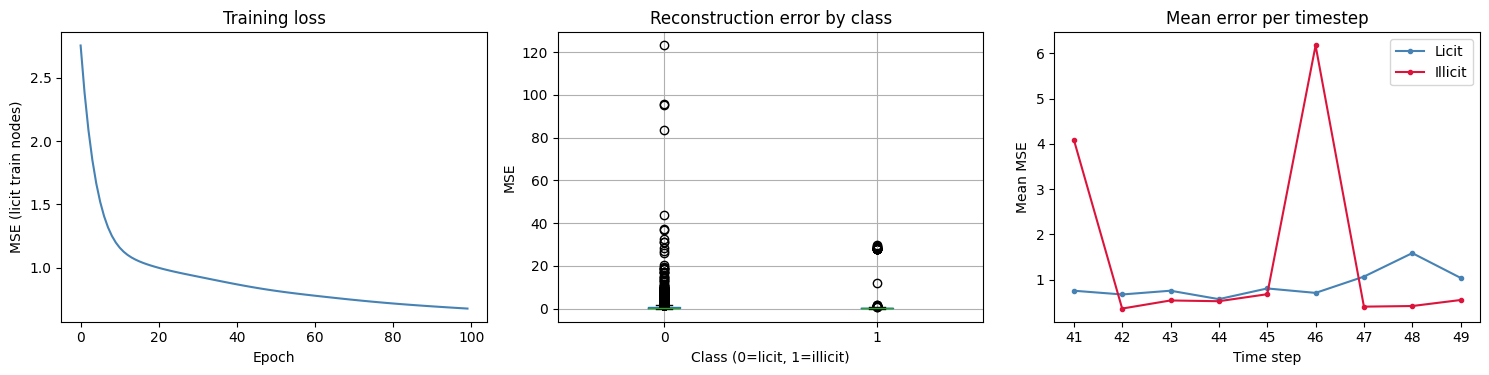

In [ ]:
model, losses, results = gae_orchestrator(                                                
    df, edges, feature_cols,              
    train_timesteps = list(range(1, 41)),                                                      
    test_timesteps = list(range(41, 50)),                                                      
    hidden_dim=64, latent_dim=16, epochs=100
)  

Same as previous methods, Graph AE finds higher reeconstruction error (with higher var) for the licit class. 

## Theory

The core difference between Static and Graph Autoencoders, is what gets reconstructed:

┌────────────────┬─────────────────────────────────┬─────────────────────────────────┐
│                │          **Static AE**          │       **Graph AE (GAE)**        │
├────────────────┼─────────────────────────────────┼─────────────────────────────────┤
│ Input          │ Feature matrix X (n×m)          │ X + Adjacency matrix A (n×n)    │
├────────────────┼─────────────────────────────────┼─────────────────────────────────┤
│ Encoder        │ MLP on node features            │ GCN — aggregates neighbor       │
│                │ independently                   │ features                        │
├────────────────┼─────────────────────────────────┼─────────────────────────────────┤
│ Decoder        │ Reconstructs node features      │ Reconstructs edges: Â = σ(ZZᵀ)  │
├────────────────┼─────────────────────────────────┼─────────────────────────────────┤
│ Graph          │ Ignored                         │ Core of the model               │
│ structure      │                                 │                                 │
└────────────────┴─────────────────────────────────┴─────────────────────────────────┘

The encoder in GAE uses Graph Convolutional layers:
Z = GCN(X, A)   # each node embedding is informed by its neighbors

So a transaction's latent representation captures not just its own features but also who 
it transacts with and how. The decoder then tries to reconstruct which transactions are   
connected — anomalous nodes fail to reconstruct their neighborhood pattern.

Justifictation: every method so far used only node       
features. GAE is the first that directly uses the graph topology for learning — which is
where the discriminating signal actually lives in this dataset. If GAE also fails, the    
conclusion is clean: unsupervised latent-space methods cannot detect anomalies in this 
heterogeneous graph regardless of whether topology is incorporated, which is a strong and
well-supported H0.


Feature-reconstruction with GAE uses 
- A GCN encoder + 
- MLP decoder reconstructing node features. 
- Anomaly score = MSE as previous AEs. 
This is directly comparable to the static AE experiments — the only difference is the encoder uses graph convolution instead of MLP. 

  # Results


- The GCN encoder aggregates neighbor features, but on this dataset neighbors are a mix of licit and illicit (the heterogeneity problem). So a fraud node's embedding becomes a weighted average of its own features plus its licit neighbors' features — which makes it look more like licit, not less. The GCN actually smooths away the fraud signal rather than amplifying it.
- The same mechanism that made neighborhood-based graph features useless in the NMF experiment applies here. The difference is that the Graph features are enriched within the encoder and not added as hand-crafted features.
- A scenario where GAE would be beneficial, is where fraud transactions cluster together in the graph enough that their aggregated neighborhood embedding is distinctly different from licit. But the dataset papers explicitly say this isn't the case — illicit nodes are scattered throughout the graph.

In [ ]:
#TODO: to verify the below

Assuming that fraud is more stereotyped/homogeneous (fewer distinct patterns than licit), it actually reconstructs better — lower error, not higher. That's the systematic < 0.5 AUC across every method. The model is  correctly learning that fraud is less diverse. It just can't use that to detect fraud because the signal is inverted.

Why GCN with labels (suppervised classification) work 
   
Supervised GCN can learn: "nodes connected to this specific pattern of neighbors are fraud" — because the fraud labels propagate through the graph during backprop. The discriminative loss explicitly teaches the model what fraud neighborhoods look like.
Unsupervised GAE sees the same graph but has no labels to anchor what illicit neighborhood means — so it just learns that all neighborhoods look approximately normal.



# Invertibability

                                                                                           
Justification: The inversion is consistent and systematic across every method, every architecture, every  split. Indicating it's a property of the data. Fraud in the Elliptic dataset is more homogeneous than licit transactions. Money laundering often involves structuring:    
- repeating similar small transactions to avoid detection thresholds. The model correctly learns this — it just learns the wrong thing for traditional anomaly detection.
The inverted signal is real and interpretable:
  - Traditional paradigm: anomaly = high reconstruction error (novelty detection)
  - Inverted paradigm: anomaly = suspiciously low reconstruction error (regularity          
  detection)                                                                      
                                                                                            
Framing: Transaction that is too easy to reconstruct - its behavior is unusually stereotyped, is a legitimate fraud signal. The detection would be for behavioral over-regularity, rather than deviation.      
                                                                                        

Standard reconstruction-based anomaly detection assumes anomalies are out-of-distribution. The consistent inversion observed across all methods reveals a secondary property of the Elliptic dataset: illicit transactions exhibit behavioral stereotypy — they are systematically more homogeneous than licit ones, reconstructing with lower error. Under an inverted detection paradigm, validated on a held-out period, this stereotypy becomes the detection signal."


does the GCN encoder, by aggregating neighborhood information, push the AUC above 0.7? If yes, graph
  topology adds signal on top of stereotypy. If it stays at ~0.7, the signal is entirely in 
  the node features and the graph contributes nothing new even for detecting regularity.

In [ ]:
def gae_inverted_orchestrator(df, edges, feature_cols,                                    
                                 train_ts=range(1,31),
                                 val_ts=range(31,41),                                       
                                 test_ts=range(41,50),
                                 hidden_dim=64, latent_dim=16,                              
                                 epochs=100, lr=1e-3):

    train_df = df[df['time_step'].isin(train_ts)]
    val_df   = df[df['time_step'].isin(val_ts)]
    test_df  = df[df['time_step'].isin(test_ts)]

    train_data, scaler = build_subgraph(train_df, edges, feature_cols)
    val_data,   _      = build_subgraph(val_df,   edges, feature_cols, scaler=scaler)     
    test_data,  _      = build_subgraph(test_df,  edges, feature_cols, scaler=scaler)     

    model = GraphAutoencoder(len(feature_cols), hidden_dim, latent_dim).to(device)        
    model, losses = train_gae(train_data.to(device), model, epochs=epochs, lr=lr)

    def get_errors(data):
        model.eval()
        with torch.no_grad():
            x  = data.x.to(device)
            ei = data.edge_index.to(device)
            return torch.mean((x - model(x, ei)) ** 2, dim=1).cpu().numpy()

    # validation: confirm direction
    val_errors  = get_errors(val_data)
    val_labeled = val_df[val_df['class'] < 2].copy()
    val_labeled['score'] = val_errors[val_df['class'].values < 2]

    auc_std = roc_auc_score(val_labeled['class'],  val_labeled['score'])
    auc_inv = roc_auc_score(val_labeled['class'], -val_labeled['score'])
    direction = -1 if auc_inv > auc_std else 1
    print(f'Validation — standard: {auc_std:.3f} | inverted: {auc_inv:.3f} | '
        f'using: {"inverted" if direction == -1 else "standard"}')

    # test
    test_errors  = get_errors(test_data)
    test_labeled = test_df[test_df['class'] < 2].copy()
    test_labeled['anomaly_score'] = direction * test_errors[test_df['class'].values < 2]  

    auc = roc_auc_score(test_labeled['class'], test_labeled['anomaly_score'])             
    ap  = average_precision_score(test_labeled['class'], test_labeled['anomaly_score'])
    print(f'Test      — ROC-AUC: {auc:.4f} | AP: {ap:.4f}')
    print(test_labeled.groupby('class')['anomaly_score'].describe())      
    plot_gae_results(losses, results)

    return model, losses, test_labeled, auc, ap


GAE — ROC-AUC: 0.2943 | AP: 0.0487
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      9449.0  0.793226  2.502940  0.079773  0.273963  0.429105  0.776891   
1       524.0  1.299217  5.240341  0.053276  0.125754  0.247810  0.490077   

              max  
class              
0      117.149857  
1       30.828806  


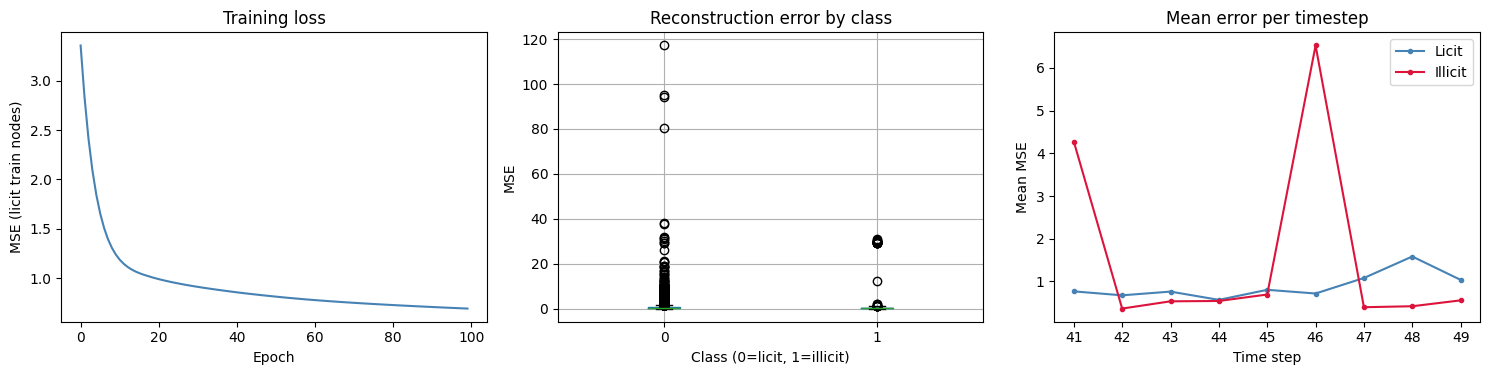

GAE — ROC-AUC: 0.2952 | AP: 0.0474
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      9449.0  0.751645  2.462115  0.075239  0.259117  0.399329  0.723082   
1       524.0  1.202590  4.815944  0.047257  0.129058  0.239036  0.435409   

              max  
class              
0      113.390221  
1       29.168262  


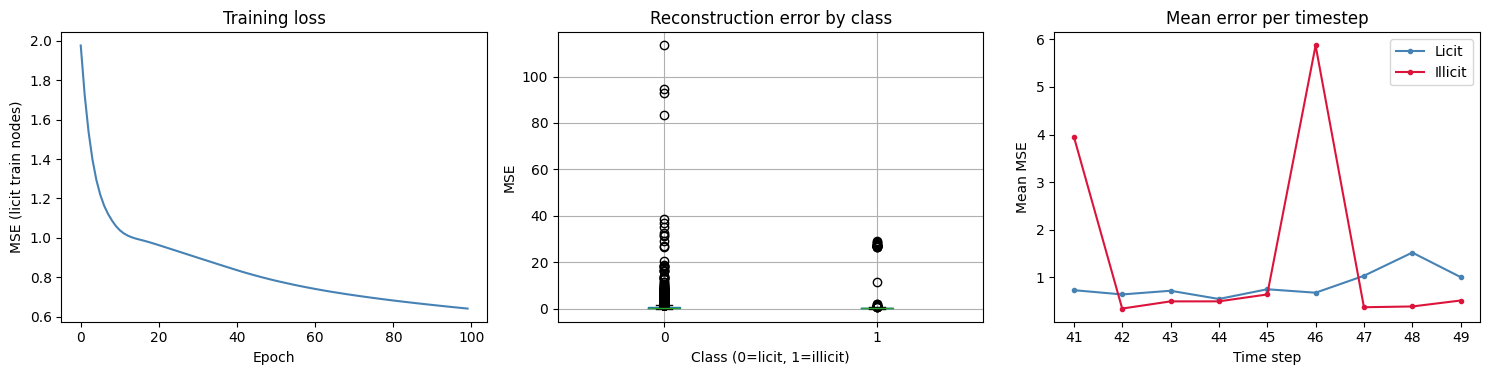

GAE — ROC-AUC: 0.2989 | AP: 0.0483
        count      mean      std       min       25%       50%       75%  \
class                                                                      
0      9449.0  0.735442  2.36090  0.068730  0.252475  0.394655  0.721755   
1       524.0  1.230780  4.99431  0.044032  0.122496  0.237929  0.443008   

              max  
class              
0      113.448784  
1       29.412680  


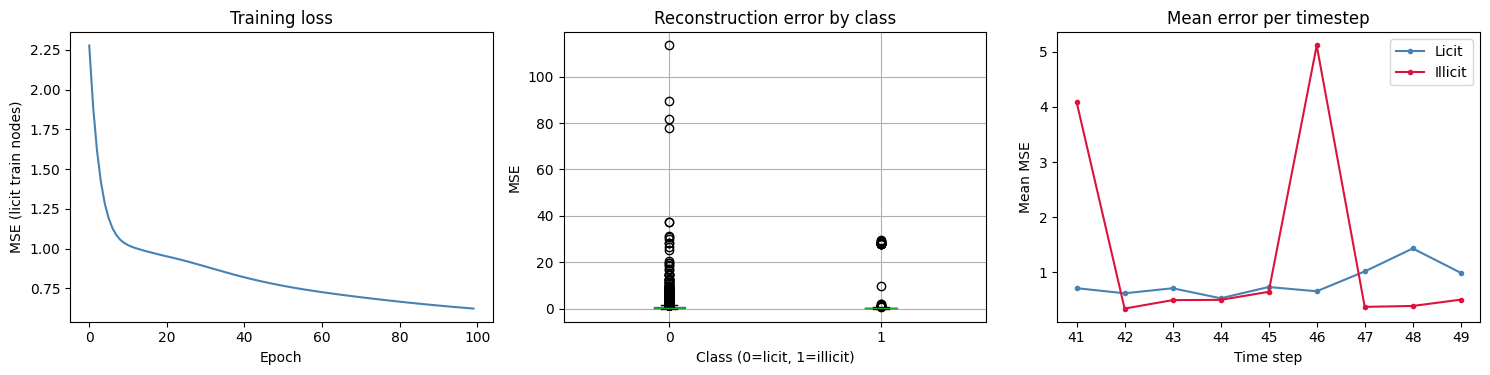

In [33]:
for dim in [16, 32, 64]: 
    model, losses, results = gae_orchestrator(
        df, edges, feature_cols,
        train_timesteps = list(range(1, 41)),
        test_timesteps = list(range(41, 50)),
        hidden_dim=64, latent_dim=dim, epochs=100
    )